# Experiment 05: ResNet34-UNet on G1020 Dataset

**Date:** 2025-10-08  
**Author:** CAP5410 Project Team  
**Objective:** Train ResNet34-UNet with CLAHE and strong augmentation on G1020 dataset

---

## 📋 Experiment Overview

### Dataset: G1020
- **Total samples:** 1020 fundus images
- **Training:** 714 samples (70%)
- **Validation:** 153 samples (15%)
- **Test:** 153 samples (15%)
- **Image size:** 430×430 (already cropped to ROI)
- **Task:** Optic disc and cup segmentation

### Model Configuration
- **Model:** ResNet34-UNet (pretrained encoder)
- **Preprocessing:** CLAHE (LAB mode, clip_limit=2.0)
- **Augmentation:** **STRONG** (p=0.8, geometric+color+blur)
- **Strategy:** Two-stage training (10 epochs frozen, 40 epochs fine-tuning)

### Hyperparameters
```python
{
    'epochs': 50,
    'freeze_encoder_epochs': 10,
    'batch_size': 4,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'augmentation_type': 'strong',
    'augmentation_p': 0.8,
}
```

---

## 1️⃣ Environment Setup

In [1]:
import sys
import os
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))

print(f"Project root: {project_root}")
print(f"Working directory: {Path.cwd()}")

Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
Working directory: /home/robolab/dev/CAP5410-roi-enhancer-odoc/experiments/05_resnet34_g1020


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Project imports
from models.resnet_unet import ResNetUNet
from data_loader.g1020_dataset import G1020Dataset
from data_loader.strong_augmentation import get_augmentation
from experiments.utils import (
    train_epoch,
    validate_epoch,
    test_model,
    plot_training_curves,
    visualize_predictions,
    save_config,
    save_history,
    save_test_results,
    print_test_results,
    print_model_info,
)
from tqdm.notebook import tqdm
from datetime import datetime

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti
Memory: 11.35 GB


## 2️⃣ Configuration

In [3]:
# Experiment configuration
CONFIG = {
    # Model
    'model': 'resnet34_unet_g1020',
    'encoder': 'resnet34',
    'pretrained': True,
    
    # Data
    'data_dir': '../../datasets/G1020',
    'train_csv': '../../datasets/G1020/G1020_train.csv',
    'val_csv': '../../datasets/G1020/G1020_val.csv',
    'test_csv': '../../datasets/G1020/G1020_test.csv',
    'images_dir': 'Images_Cropped/img',
    'masks_dir': 'Masks_Cropped/img',
    'use_clahe': True,
    
    # CLAHE parameters
    'clahe_clip_limit': 2.0,
    'clahe_tile_size': (8, 8),
    'clahe_mode': 'LAB',
    
    # Augmentation
    'use_augmentation': True,
    'augmentation_type': 'strong',
    'augmentation_p': 0.8,
    
    # Training
    'epochs': 50,
    'freeze_encoder_epochs': 10,
    'batch_size': 4,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'num_workers': 4,
    
    # Output
    'output_dir': './results',
}

# Create output directory
os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/visualizations", exist_ok=True)

# Save configuration
save_config(CONFIG, f"{CONFIG['output_dir']}/config.json")

print("🚀 G1020 EXPERIMENT CONFIGURATION:")
print(f"   Dataset: G1020 (714 train / 153 val / 153 test)")
print(f"   Model: {CONFIG['model']}")
print(f"   Augmentation: {CONFIG['augmentation_type'].upper()} (p={CONFIG['augmentation_p']})")
print(f"   Batch size: {CONFIG['batch_size']}")
print(f"   Epochs: {CONFIG['epochs']} (freeze encoder: {CONFIG['freeze_encoder_epochs']})")

✅ Configuration saved to ./results/config.json
🚀 G1020 EXPERIMENT CONFIGURATION:
   Dataset: G1020 (714 train / 153 val / 153 test)
   Model: resnet34_unet_g1020
   Augmentation: STRONG (p=0.8)
   Batch size: 4
   Epochs: 50 (freeze encoder: 10)


## 3️⃣ Data Loading

In [4]:
# Create augmentation pipeline
if CONFIG['use_augmentation']:
    train_augmentor = get_augmentation(CONFIG['augmentation_type'])
    print(f"✅ Using {CONFIG['augmentation_type']} augmentation for training")
else:
    train_augmentor = None
    print("⚠️  No augmentation")

# Create datasets
print("\nLoading G1020 datasets...")

train_dataset = G1020Dataset(
    csv_file=CONFIG['train_csv'],
    root_dir=CONFIG['data_dir'],
    images_dir=CONFIG['images_dir'],
    masks_dir=CONFIG['masks_dir'],
    use_clahe=CONFIG['use_clahe'],
    clahe_clip_limit=CONFIG['clahe_clip_limit'],
    clahe_mode=CONFIG['clahe_mode'],
    augmentation=train_augmentor,
)

val_dataset = G1020Dataset(
    csv_file=CONFIG['val_csv'],
    root_dir=CONFIG['data_dir'],
    images_dir=CONFIG['images_dir'],
    masks_dir=CONFIG['masks_dir'],
    use_clahe=CONFIG['use_clahe'],
    clahe_clip_limit=CONFIG['clahe_clip_limit'],
    clahe_mode=CONFIG['clahe_mode'],
    augmentation=None,  # No augmentation on validation
)

test_dataset = G1020Dataset(
    csv_file=CONFIG['test_csv'],
    root_dir=CONFIG['data_dir'],
    images_dir=CONFIG['images_dir'],
    masks_dir=CONFIG['masks_dir'],
    use_clahe=CONFIG['use_clahe'],
    clahe_clip_limit=CONFIG['clahe_clip_limit'],
    clahe_mode=CONFIG['clahe_mode'],
    augmentation=None,  # No augmentation on test
)

print(f"✅ Train samples: {len(train_dataset)} (with augmentation)")
print(f"✅ Validation samples: {len(val_dataset)} (no augmentation)")
print(f"✅ Test samples: {len(test_dataset)} (no augmentation)")

# Check data
sample_img, sample_mask = train_dataset[0]
print(f"\n📊 Data shapes:")
print(f"   Image: {sample_img.shape}")
print(f"   Mask: {sample_mask.shape} (disc + cup)")

✅ Using strong augmentation for training

Loading G1020 datasets...
✅ Train samples: 714 (with augmentation)
✅ Validation samples: 153 (no augmentation)
✅ Test samples: 153 (no augmentation)

📊 Data shapes:
   Image: torch.Size([3, 512, 512])
   Mask: torch.Size([2, 512, 512]) (disc + cup)


In [5]:
# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print("✅ Data loaders created")
print(f"   Train batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

✅ Data loaders created
   Train batches: 179
   Validation batches: 39
   Test batches: 39


## 4️⃣ Model Definition

In [6]:
# Create model
model = ResNetUNet(
    backbone=CONFIG['encoder'],
    pretrained=CONFIG['pretrained'],
    n_classes=2
).to(device)

# Print model info
print_model_info(model, title=f"✅ Model created: {CONFIG['model']}")

/home/robolab/dev/CAP5410-roi-enhancer-odoc/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/robolab/dev/CAP5410-roi-enhancer-odoc/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



✅ Model created: resnet34_unet_g1020
  Total parameters: 24,534,946
  Trainable parameters: 24,534,946


In [7]:
# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

print("✅ Loss function and optimizer defined")

✅ Loss function and optimizer defined


## 5️⃣ Two-Stage Training

**Training strategy:**
- **Stage 1 (Epochs 0-9):** Freeze encoder, train decoder only
- **Stage 2 (Epochs 10-49):** Unfreeze encoder, fine-tune full model

In [8]:
# Clear GPU memory before training
import gc
torch.cuda.empty_cache()
gc.collect()

# Check available GPU memory
if torch.cuda.is_available():
    memory_allocated = torch.cuda.memory_allocated(0) / 1e9
    memory_reserved = torch.cuda.memory_reserved(0) / 1e9
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    free_memory = total_memory - memory_allocated
    
    print(f"💾 GPU Memory Status:")
    print(f"   Total: {total_memory:.2f} GB")
    print(f"   Allocated: {memory_allocated:.2f} GB")
    print(f"   Reserved: {memory_reserved:.2f} GB")
    print(f"   Free: {free_memory:.2f} GB")
    print(f"✅ GPU memory cleared and ready for training!")

💾 GPU Memory Status:
   Total: 11.35 GB
   Allocated: 0.10 GB
   Reserved: 0.12 GB
   Free: 11.25 GB
✅ GPU memory cleared and ready for training!


In [9]:
# Two-stage training with encoder freezing
history = {
    'train_loss': [],
    'train_dice': [],
    'val_loss': [],
    'val_dice': [],
    'val_dice_disc': [],
    'val_dice_cup': [],
}

best_dice = 0.0
start_time = datetime.now()

print(f"\n{'='*60}")
print("Starting TWO-STAGE training on G1020 dataset...")
print(f"Stage 1: Epochs 0-{CONFIG['freeze_encoder_epochs']-1} (encoder frozen)")
print(f"Stage 2: Epochs {CONFIG['freeze_encoder_epochs']}-{CONFIG['epochs']-1} (full fine-tuning)")
print(f"Augmentation: {CONFIG['augmentation_type']} (p={CONFIG['augmentation_p']})")
print(f"{'='*60}\n")

for epoch in range(CONFIG['epochs']):
    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
    print("-" * 60)
    
    # Freeze/unfreeze encoder
    if epoch == CONFIG['freeze_encoder_epochs']:
        print("\n🔓 UNFREEZING ENCODER - Starting full fine-tuning\n")
        model.unfreeze_encoder()
        print_model_info(model, title="Updated model info")
    elif epoch == 0:
        print("\n🔒 FREEZING ENCODER - Training decoder only\n")
        model.freeze_encoder()
        print_model_info(model, title="Initial model info")
    
    # Train
    train_loss, train_dice = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_metrics = validate_epoch(model, val_loader, criterion, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['val_loss'].append(val_metrics['loss'])
    history['val_dice'].append(val_metrics['dice_mean'])
    history['val_dice_disc'].append(val_metrics['dice_disc'])
    history['val_dice_cup'].append(val_metrics['dice_cup'])
    
    # Calculate overfitting gap
    gap = train_dice - val_metrics['dice_mean']
    
    # Print summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f}")
    print(f"  Val Loss:   {val_metrics['loss']:.4f} | Val Dice:   {val_metrics['dice_mean']:.4f}")
    print(f"  Val Disc:   {val_metrics['dice_disc']:.4f} | Val Cup:    {val_metrics['dice_cup']:.4f}")
    print(f"  Overfitting Gap: {gap:.4f} ({gap*100:.1f}%)")
    
    # Evaluate gap
    if gap < 0.05:
        print(f"  ✅ Healthy gap (< 5%)")
    elif gap < 0.10:
        print(f"  ⚠️  Moderate gap (5-10%)")
    else:
        print(f"  ❌ Large gap (> 10%) - overfitting!")
    
    # Save best model
    if val_metrics['dice_mean'] > best_dice:
        best_dice = val_metrics['dice_mean']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics': val_metrics,
            'args': CONFIG,
        }, f"{CONFIG['output_dir']}/best_model.pth")
        print(f"  ✅ Best model saved (Dice: {best_dice:.4f})")

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds() / 3600

print(f"\n{'='*60}")
print(f"Training completed in {training_time:.2f} hours")
print(f"Best validation Dice: {best_dice:.4f} ({best_dice*100:.2f}%)")
print(f"{'='*60}")

# Save training history
save_history(history, f"{CONFIG['output_dir']}/training_history.json")


Starting TWO-STAGE training on G1020 dataset...
Stage 1: Epochs 0-9 (encoder frozen)
Stage 2: Epochs 10-49 (full fine-tuning)
Augmentation: strong (p=0.8)


Epoch 1/50
------------------------------------------------------------

🔒 FREEZING ENCODER - Training decoder only

Encoder frozen. Only decoder will be trained.

Initial model info
  Total parameters: 24,534,946
  Trainable parameters: 3,250,274
  Frozen parameters: 21,284,672


Validation: 100%|██████████| 39/39 [00:02<00:00, 14.08it/s, loss=0.3586, dice=0.6259]



Epoch 1 Summary:
  Train Loss: 0.4282 | Train Dice: 0.5253
  Val Loss:   0.3660 | Val Dice:   0.5592
  Val Disc:   0.8234 | Val Cup:    0.2951
  Overfitting Gap: -0.0339 (-3.4%)
  ✅ Healthy gap (< 5%)
  ✅ Best model saved (Dice: 0.5592)

Epoch 2/50
------------------------------------------------------------


Validation: 100%|██████████| 39/39 [00:02<00:00, 14.76it/s, loss=0.3203, dice=0.6497]



Epoch 2 Summary:
  Train Loss: 0.3372 | Train Dice: 0.5763
  Val Loss:   0.3182 | Val Dice:   0.5811
  Val Disc:   0.8345 | Val Cup:    0.3277
  Overfitting Gap: -0.0048 (-0.5%)
  ✅ Healthy gap (< 5%)
  ✅ Best model saved (Dice: 0.5811)

Epoch 3/50
------------------------------------------------------------


...


Epoch 48 Summary:
  Train Loss: 0.1155 | Train Dice: 0.8294
  Val Loss:   0.1176 | Val Dice:   0.8195
  Val Disc:   0.9524 | Val Cup:    0.6867
  Overfitting Gap: 0.0099 (1.0%)
  ✅ Healthy gap (< 5%)

Epoch 49/50
------------------------------------------------------------


Validation: 100%|██████████| 39/39 [00:02<00:00, 16.29it/s, loss=0.1057, dice=0.8773]



Epoch 49 Summary:
  Train Loss: 0.1149 | Train Dice: 0.8276
  Val Loss:   0.1491 | Val Dice:   0.7951
  Val Disc:   0.9415 | Val Cup:    0.6486
  Overfitting Gap: 0.0325 (3.2%)
  ✅ Healthy gap (< 5%)

Epoch 50/50
------------------------------------------------------------


Validation: 100%|██████████| 39/39 [00:02<00:00, 16.00it/s, loss=0.1063, dice=0.8707]


Epoch 50 Summary:
  Train Loss: 0.1128 | Train Dice: 0.8311
  Val Loss:   0.1212 | Val Dice:   0.8246
  Val Disc:   0.9506 | Val Cup:    0.6986
  Overfitting Gap: 0.0064 (0.6%)
  ✅ Healthy gap (< 5%)

Training completed in 0.47 hours
Best validation Dice: 0.8285 (82.85%)
✅ Training history saved to ./results/training_history.json


### 📈 Training Curves

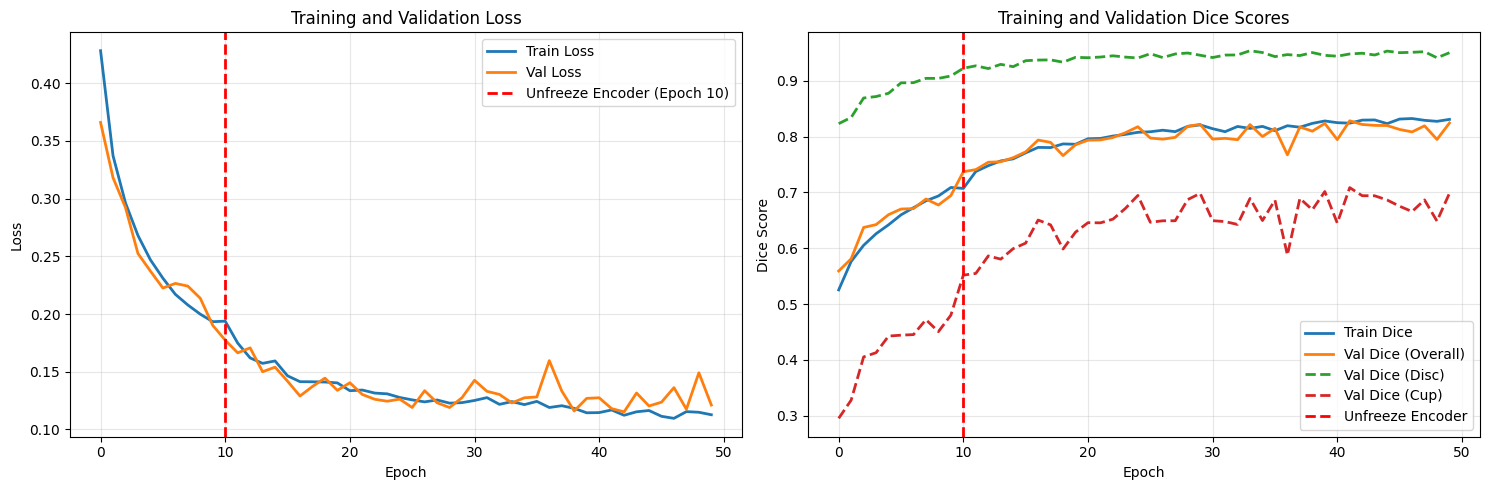

In [10]:
# Plot training curves with freeze/unfreeze marker
plot_training_curves(
    history=history,
    output_path=f"{CONFIG['output_dir']}/training_curves.png",
    freeze_epoch=CONFIG['freeze_encoder_epochs']
)

## 6️⃣ Testing

In [11]:
# Load best model
checkpoint = torch.load(f"{CONFIG['output_dir']}/best_model.pth", weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print("✅ Best model loaded")
print(f"   Trained on epoch: {checkpoint['epoch']}")
print(f"   Validation Dice: {checkpoint['metrics']['dice_mean']:.4f}")

✅ Best model loaded
   Trained on epoch: 41
   Validation Dice: 0.8285


In [12]:
# Test model
test_results, predictions, masks = test_model(
    model=model,
    test_loader=test_loader,
    device=device
)

# Print and save results
print_test_results(test_results, title="TEST RESULTS (G1020 DATASET)")
save_test_results(test_results, f"{CONFIG['output_dir']}/test_results.json")

Testing: 100%|██████████| 39/39 [00:02<00:00, 13.77it/s, dice=0.8027, cdr_mae=0.1004]



TEST RESULTS (G1020 DATASET)
Overall Dice Score:     0.8402 (84.02%)
Disc Dice Score:        0.9471 (94.71%)
Cup Dice Score:         0.7332 (73.32%)
CDR Mean Absolute Error: 0.0512
✅ Test results saved to ./results/test_results.json


### 🖼️ Visualizations

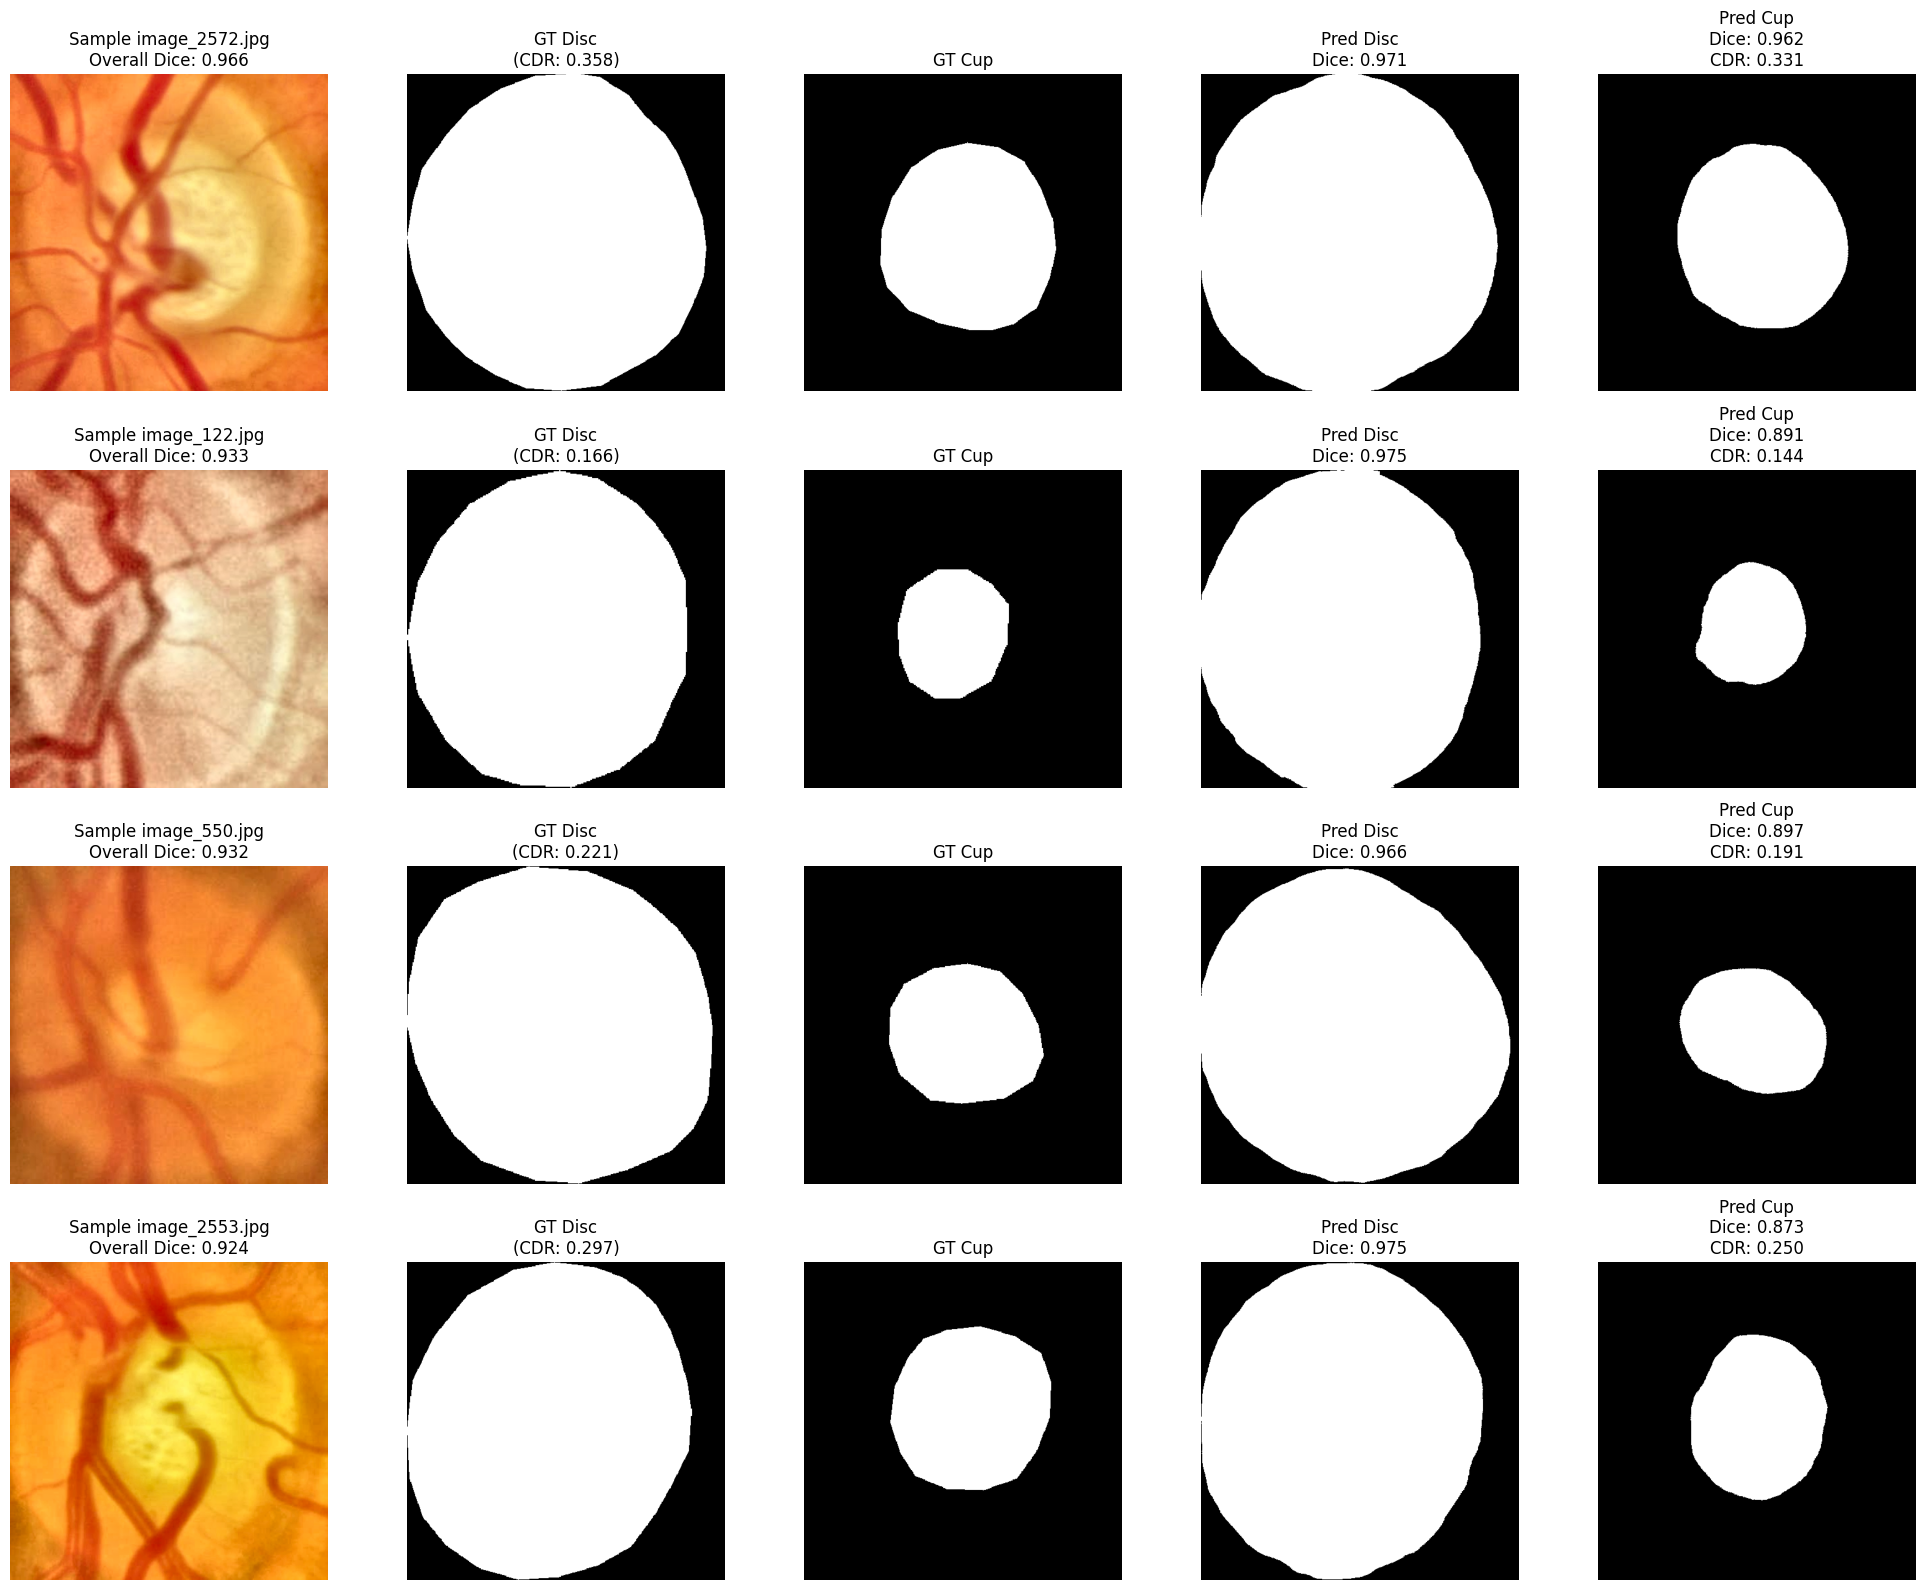

In [13]:
# Visualize predictions
visualize_predictions(
    test_dataset=test_dataset,
    predictions=predictions,
    masks=masks,
    output_path=f"{CONFIG['output_dir']}/visualizations/test_predictions.png",
    num_samples=4,
    seed=42
)

## 📊 Results Summary

### Expected Performance
Based on Experiment 04 (REFUGE with strong augmentation):
- **Training Dice:** 70-80%
- **Validation Dice:** 73-78%
- **Overfitting Gap:** 2-5%

### G1020 vs REFUGE

| Metric | REFUGE (Exp 04) | G1020 (Exp 05) |
|--------|-----------------|----------------|
| **Dataset Size** | 400 train | 714 train |
| **Image Size** | 432×494 | 430×430 |
| **Train Dice** | TBD | TBD |
| **Val Dice** | TBD | TBD |
| **Test Dice** | TBD | TBD |

---

**Note:** All results, visualizations, and model checkpoints are saved in `./results/`